In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import re,sys,os
import pandas as pd
import numpy as np
from tqdm import tqdm
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib

# Set font to Arial
matplotlib.rcParams['font.family'] = 'Arial'

# Optional: Set PDF to embed fonts (for Illustrator editing)
matplotlib.rcParams['pdf.fonttype'] = 42  # TrueType fonts for better editing

In [3]:
DATA_DIR = Path(r"E:\lab\cptac-prostate\20260401_quality_control")
OUTPUT_DIR = Path(r"E:\lab\cptac-prostate\20260401_mspycloud_cptac_protein_tmt_pca")
OUTPUT_DIR.mkdir(exist_ok=True)
print(DATA_DIR.exists(), OUTPUT_DIR.exists())
meta_path = DATA_DIR / "20_MetaData_03_12_2026_renamed.csv"

True True


In [4]:
meta = pd.read_csv(meta_path)
meta

,case_id,common_ID,Tissuetype,include_or_excludetumor,FirstCategory,AdditionalSegments,SecondCategory,ThirdCategory,all_drivers,Main_Groups,...,Normal_Pam50,Basal,Her2,LumA,LumB,Normal,agg_rank_raw,agg_rank_scaled,risk_group,SampleID
0,C3L-07287,C3L.07287.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.000000,0.0,0.0,1.0,0.0,0.0,55.333000,0.409000,IR,C3L-07287_T
1,C3L-11156,C3L.11156.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.498000,0.0,0.0,1.0,0.0,0.0,44.167000,0.325000,LR,C3L-11156_T
2,C3L-09494,C3L.09494.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.000000,0.0,1.0,0.0,0.0,0.0,123.167000,0.919000,HR,C3L-09494_T
3,CHTN-49141,CHTN.49141.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.000000,0.0,1.0,0.0,0.0,0.0,103.833000,0.773000,HR,CHTN-49141_T
4,C3L-11095,C3L.11095.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.369000,0.0,0.0,1.0,0.0,0.0,44.667000,0.328000,LR,C3L-11095_T
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,C3L-07872,C3L.07872.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.460832,1.0,0.0,0.0,0.0,0.0,73.666667,0.546366,IR,C3L-07872_T
179,C3L-08642,C3L.08642.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.334840,0.0,0.0,1.0,0.0,0.0,46.166667,0.339599,LR,C3L-08642_T
180,C3L-10399,C3L.10399.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.445334,0.0,0.0,1.0,0.0,0.0,60.000000,0.443609,IR,C3L-10399_T
181,C3L-05301,C3L.05301.T,tumor,Include,Low Purity,NaN,NaN,NaN,ETV1,ETV1,...,0.457908,0.0,0.0,1.0,0.0,0.0,45.333333,0.333333,LR,C3L-05301_T


In [5]:
meta_normal = meta[meta["Tissuetype"] == "normal"]

In [6]:
purity_map = dict(zip(meta["SampleID"], meta["FirstCategory"]))
stage_map = dict(zip(meta["SampleID"], meta["stage"]))
gleason_map = dict(zip(meta["SampleID"], meta["Grade_Group"]))

In [7]:
meta_tumor = meta[meta["Tissuetype"] == "tumor"]

In [8]:
tumors_included = meta_tumor['SampleID'].tolist()
print(len(tumors_included))

150


In [9]:
normals = meta_normal['SampleID'].tolist()
print(len(normals))

33


In [10]:
# data
files = [i for i in DATA_DIR.iterdir() if i.is_file()]
files = [i for i in files if re.search(r"mspycloud_Global_DDA_TMT_log2ratio",i.stem, re.IGNORECASE) \
    and not re.search(r"tumor_purity_corrected",i.stem, re.IGNORECASE)]
data_path = files[0]
protein_header_cols = ["Protein.Group.Accessions"]
data = pd.read_csv(data_path,sep="\t").set_index(protein_header_cols)
data_nomiss = data.dropna()

In [11]:
print(data_path)

E:\lab\cptac-prostate\20260401_quality_control\mspycloud_Global_DDA_TMT_log2ratio_Clean_MD.tsv


In [12]:
data

,Reference Sample 1,C3L-05292_T,C3L-09383_T,CHTN-43798_T,C3L-06261_N,C3L-08811_T,C3L-06506_N,C3L-07804_T,C3L-06595_T,C3L-06742_T,...,CHTN-44966_T,C3L-11192_N,C3L-08805_T,C3L-09760_T,C3L-08444_T,C3L-08291_T,C3L-10583_T,C3L-07877_T,C3L-08377_T,C3L-08736_T
Protein.Group.Accessions,,,,,,,,,,,,,,,,,,,,,
ENSP00000000233|ENST00000000233|ENSG00000004059|ARF5 ADP ribosylation factor 5,0.0,0.077017,-0.187993,-0.137950,-0.255903,0.235679,-0.122157,0.049047,-0.150472,0.090129,...,0.177651,-0.184215,-0.495843,0.065143,0.050001,0.262834,-0.221609,0.084544,-0.024535,0.266896
"ENSP00000000412|ENST00000000412|ENSG00000003056|M6PR mannose-6-phosphate receptor, cation dependent",0.0,0.122390,0.036646,0.179340,0.038353,0.361856,0.023644,-0.226568,-0.218785,-0.029380,...,-0.210005,-0.509339,0.323025,0.112554,-0.003882,-0.364879,-0.290935,0.175473,0.113948,0.242116
ENSP00000001008|ENST00000001008|ENSG00000004478|FKBP4 FKBP prolyl isomerase 4,0.0,-0.158774,-0.185559,-0.186552,-0.403156,0.400005,-0.286488,-0.581658,-0.184171,0.472634,...,-0.235445,-0.561989,-0.306163,0.162003,0.084839,0.157711,-0.421211,-0.058981,-0.186794,0.220484
ENSP00000002125|ENST00000002125|ENSG00000003509|NDUFAF7 NADH:ubiquinone oxidoreductase complex assembly factor 7,0.0,-0.007247,0.085730,-0.037076,-0.063520,0.155436,-0.019618,-0.203342,0.050553,-0.125149,...,-0.261797,0.020816,0.195666,0.066049,0.017390,-0.083763,0.028189,-0.052304,-0.023878,0.302151
ENSP00000002165|ENST00000002165|ENSG00000001036|FUCA2 alpha-L-fucosidase 2,0.0,0.075815,0.295018,0.097095,-0.751552,0.072959,-0.744420,-1.052637,-0.236417,0.532446,...,0.024258,-0.138183,-0.132877,0.102094,-0.293056,0.623585,-0.611337,-0.503879,0.224542,0.707597
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSP00000307014|ENST00000305748|ENSG00000186049|KRT73 keratin 73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.705524,1.032750,-0.274949,-0.305077,0.167676,-0.272981,0.215760,0.833478,0.328482,-0.000854
"ENSP00000312070|ENST00000308177|ENSG00000240184|PCDHGC3 protocadherin gamma subfamily C, 3",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.016368,0.176268,0.339498,0.119363,0.172382,-0.108952,0.503057,0.065289,0.034634,-0.416416
ENSP00000452370|ENST00000557607|ENSG00000100722|ZC3H14 zinc finger CCCH-type containing 14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.492035,0.539346,-0.074879,-0.652922,-0.225059,0.028898,0.282637,-0.544384,0.020144,0.257734


In [13]:
data_nomiss

,Reference Sample 1,C3L-05292_T,C3L-09383_T,CHTN-43798_T,C3L-06261_N,C3L-08811_T,C3L-06506_N,C3L-07804_T,C3L-06595_T,C3L-06742_T,...,CHTN-44966_T,C3L-11192_N,C3L-08805_T,C3L-09760_T,C3L-08444_T,C3L-08291_T,C3L-10583_T,C3L-07877_T,C3L-08377_T,C3L-08736_T
Protein.Group.Accessions,,,,,,,,,,,,,,,,,,,,,
ENSP00000000233|ENST00000000233|ENSG00000004059|ARF5 ADP ribosylation factor 5,0.0,0.077017,-0.187993,-0.137950,-0.255903,0.235679,-0.122157,0.049047,-0.150472,0.090129,...,0.177651,-0.184215,-0.495843,0.065143,0.050001,0.262834,-0.221609,0.084544,-0.024535,0.266896
"ENSP00000000412|ENST00000000412|ENSG00000003056|M6PR mannose-6-phosphate receptor, cation dependent",0.0,0.122390,0.036646,0.179340,0.038353,0.361856,0.023644,-0.226568,-0.218785,-0.029380,...,-0.210005,-0.509339,0.323025,0.112554,-0.003882,-0.364879,-0.290935,0.175473,0.113948,0.242116
ENSP00000001008|ENST00000001008|ENSG00000004478|FKBP4 FKBP prolyl isomerase 4,0.0,-0.158774,-0.185559,-0.186552,-0.403156,0.400005,-0.286488,-0.581658,-0.184171,0.472634,...,-0.235445,-0.561989,-0.306163,0.162003,0.084839,0.157711,-0.421211,-0.058981,-0.186794,0.220484
ENSP00000002125|ENST00000002125|ENSG00000003509|NDUFAF7 NADH:ubiquinone oxidoreductase complex assembly factor 7,0.0,-0.007247,0.085730,-0.037076,-0.063520,0.155436,-0.019618,-0.203342,0.050553,-0.125149,...,-0.261797,0.020816,0.195666,0.066049,0.017390,-0.083763,0.028189,-0.052304,-0.023878,0.302151
ENSP00000002165|ENST00000002165|ENSG00000001036|FUCA2 alpha-L-fucosidase 2,0.0,0.075815,0.295018,0.097095,-0.751552,0.072959,-0.744420,-1.052637,-0.236417,0.532446,...,0.024258,-0.138183,-0.132877,0.102094,-0.293056,0.623585,-0.611337,-0.503879,0.224542,0.707597
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSP00000516132|ENST00000705486|ENSG00000122545|SEPTIN7 septin 7,0.0,-0.030280,0.140168,-0.129239,0.383708,-0.319526,0.122037,0.285753,-0.148950,-0.009774,...,0.136409,0.295881,-0.291028,-0.187064,-0.140111,-0.211337,0.218428,0.083561,0.117416,-0.142389
ENSP00000516158|ENST00000705663|ENSG00000133226|SRRM1 serine and arginine repetitive matrix 1;ENSP00000516159|ENST00000705681|ENSG00000133226|SRRM1 serine and arginine repetitive matrix 1;ENSP00000516160|ENST00000705682|ENSG00000133226|SRRM1 serine and arginine repetitive matrix 1,0.0,-0.048635,-0.047035,-0.106103,-0.249556,0.188876,0.063482,0.191035,0.105759,0.884339,...,-0.450070,-0.231790,-0.506753,-0.123944,-0.008174,0.107305,-0.487922,-0.168650,-0.347144,-0.408744
"ENSP00000516165|ENST00000705719|ENSG00000182446|NPLOC4 NPL4 homolog, ubiquitin recognition factor",0.0,0.056546,-0.065568,0.211478,0.110925,-0.107954,-0.006579,0.146572,-0.106934,0.117629,...,0.061139,0.184662,-0.043487,0.042480,0.012310,0.074150,-0.004907,0.012809,0.015314,0.166428


In [14]:
samples = data.columns.tolist()
len(samples)

216

In [15]:
set_tumors = set(tumors_included)
set_normals = set(normals)
set_data = set(samples)
print((len(tumors_included), len(set_normals), len(set_data)))

(150, 33, 216)


In [16]:
set_data - set_tumors - set_normals

{'C3L-06436_T',
 'C3L-07292_N',
 'C3L-07606_N',
 'C3L-08546_T',
 'C3L-09345_T',
 'C3L-09373_T',
 'C3L-09793_T',
 'C3L-09832_T',
 'C3L-09972_T',
 'C3L-10301_T',
 'CHTN-47295_T',
 'NCI7_1',
 'NCI7_10',
 'NCI7_11',
 'NCI7_12',
 'NCI7_2',
 'NCI7_3',
 'NCI7_4',
 'NCI7_5',
 'NCI7_7',
 'NCI7_8',
 'Reference Sample 1',
 'Reference Sample 10',
 'Reference Sample 11',
 'Reference Sample 12',
 'Reference Sample 2',
 'Reference Sample 3',
 'Reference Sample 4',
 'Reference Sample 5',
 'Reference Sample 6',
 'Reference Sample 7',
 'Reference Sample 8',
 'Reference Sample 9'}

<Axes: >

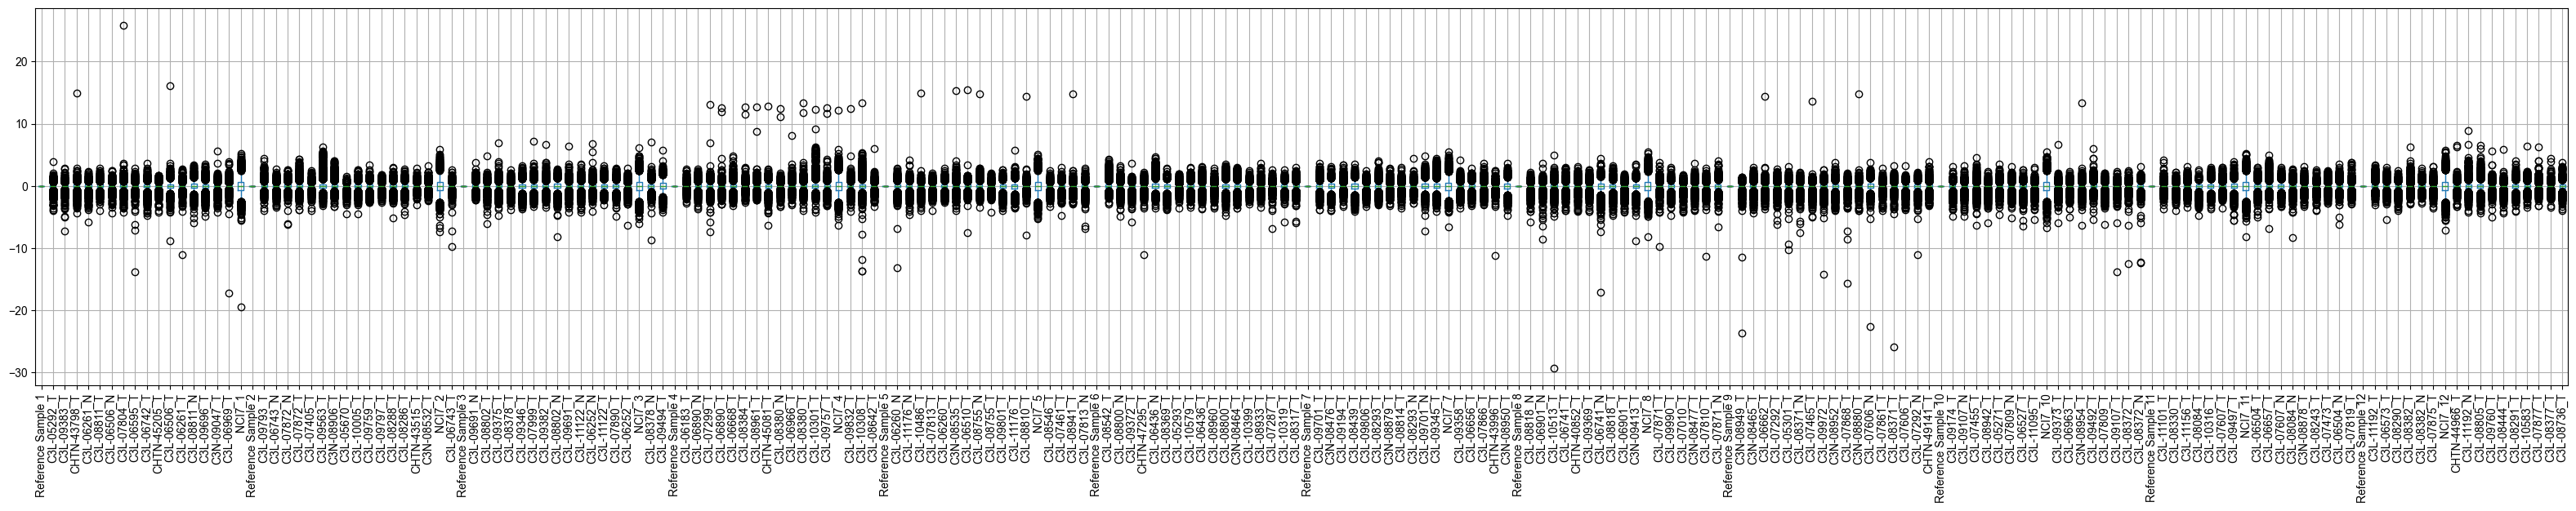

In [17]:
data.boxplot(figsize=(40,6), rot=90)

In [18]:
from omicsone_streamlit.plots.pca import plot_pca1

In [19]:
print(len(tumors_included), len(normals))

150 33


In [20]:
group_map = dict()
for i in tumors_included + normals:
    # print(i)
    if i in tumors_included:
        group_map[i] = "Tumor"
    elif i in normals:
        group_map[i] = "Normal"
    else:
        group_map[i] = "Other"

In [21]:
len(set(data.columns) & set(tumors_included))

150

In [22]:
data2 = data_nomiss.T.loc[tumors_included + normals,:]
data2['Group'] = data2.index.map(group_map)
data2 = data2.sort_values(by='Group')

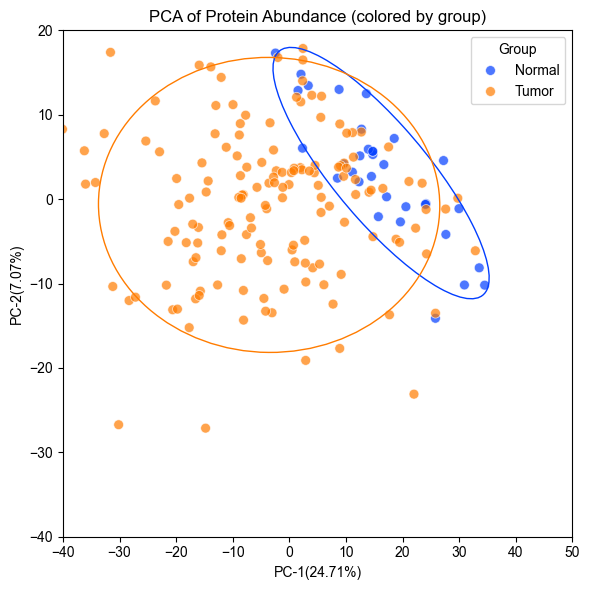

In [23]:
fig,pca = plot_pca1(data2, n=1, palette='bright', 
                    xlim=(-40,50), ylim=(-40,20), figsize=(6,6),
                    title="PCA of Protein Abundance (colored by group)")

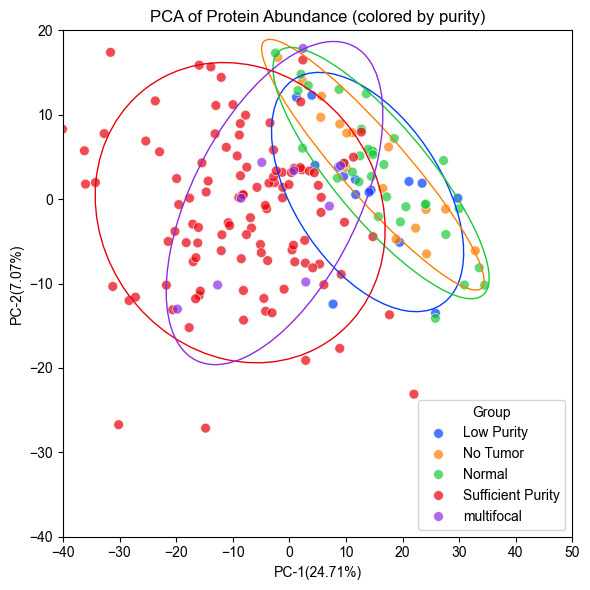

In [24]:
group_map = dict()
for i in tumors_included + normals:
    # print(i)
    if i in tumors_included:
        group_map[i] = purity_map.get(i, "Tumor")
    elif i in normals:
        group_map[i] = "Normal"
    else:
        group_map[i] = "Other"
data2['Group'] = data2.index.map(group_map)
data2 = data2.sort_values(by='Group')
fig,pca = plot_pca1(data2, n=1, palette='bright', 
                    xlim=(-40,50), ylim=(-40,20), figsize=(6,6),
                    title="PCA of Protein Abundance (colored by purity)")

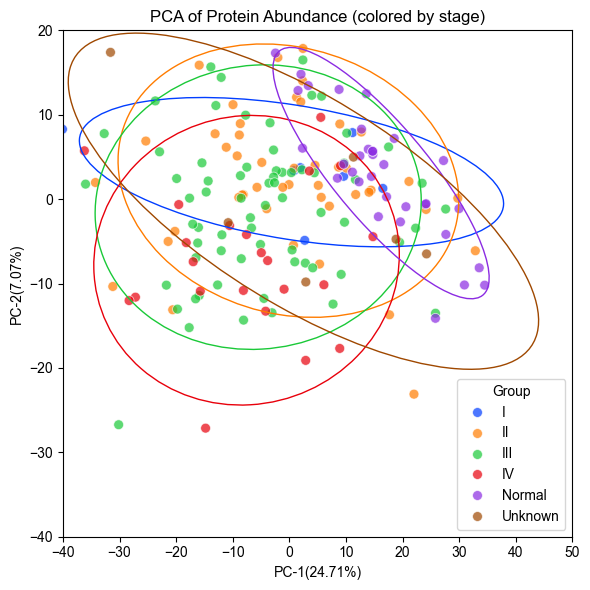

In [25]:
group_map = dict()
for i in tumors_included + normals:
    # print(i)
    if i in tumors_included:
        group_map[i] = re.sub("[ABC]",'',stage_map.get(i, "Tumor"))
    elif i in normals:
        group_map[i] = "Normal"
    else:
        group_map[i] = "Other"
data2['Group'] = data2.index.map(group_map)
data2 = data2.sort_values(by='Group')
fig,pca = plot_pca1(data2, n=1, palette='bright', 
                    xlim=(-40,50), ylim=(-40,20), figsize=(6,6),
                    title="PCA of Protein Abundance (colored by stage)")

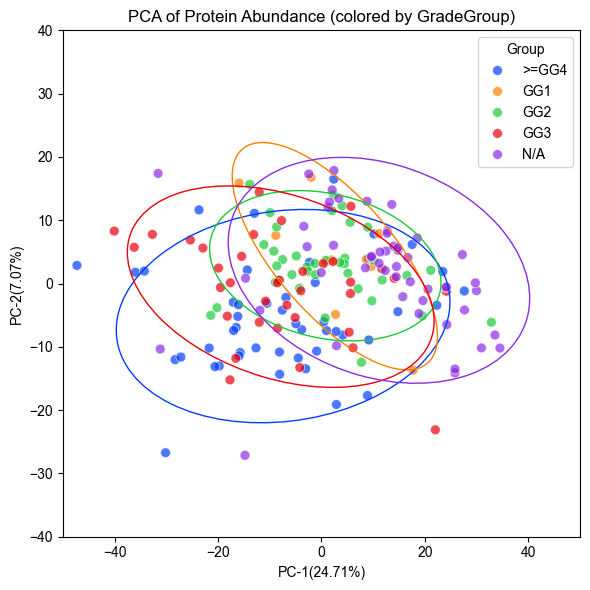

In [33]:
group_map = dict()
for i in tumors_included + normals:
    # print(i)
    if i in tumors_included:
        group_map[i] = str(gleason_map.get(i, "N/A"))
    elif i in normals:
        group_map[i] = "Normal"
    else:
        group_map[i] = "Other"
for i in group_map:
    group_map[i] = 'N/A' if not re.search("GG", group_map[i]) else group_map[i]
data2['Group'] = data2.index.map(group_map)
data2 = data2.sort_values(by='Group')
fig,pca = plot_pca1(data2, n=1, palette='bright', 
                    xlim=(-50,50), ylim=(-40,40), figsize=(6,6),
                    title="PCA of Protein Abundance (colored by GradeGroup)")